Nama : Felycia Edelyne Irwan

NIM : 36240014

Kelas: 4PDS51

# 1. Data Discovery

## Bagian 1 - Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score



## Bagian 2 - Load Dataset

### Load users.csv

In [2]:
user = pd.read_csv('users.csv')
user.head()

,user_id,employee_id,dept,role,clearance,location,status
0,U0001,E00001,Data Science,analyst,public,Surabaya,active
1,U0002,E00002,HR,manager,public,Surabaya,active
2,U0003,E00003,Legal,analyst,restricted,Jakarta,active
3,U0004,E00004,HR,manager,public,Surabaya,active
4,U0005,E00005,Data Science,admin,restricted,Jakarta,active


### Load assets.csv

In [3]:
asset = pd.read_csv('assets.csv')
asset.head()

,asset_id,asset_type,data_classification
0,cust_db,database,restricted
1,payroll,database,confidential
2,crm,saas,confidential
3,data_lake,storage,restricted
4,git_repo,code,internal


### Load sample_stream_events.csv

In [4]:
stream_event = pd.read_csv('sample_stream_events.csv')
stream_event.head()

,event_id,event_time,user_id,dept,role,device_type,source_ip,asset_id,asset_type,data_classification,action,status,bytes_out,records_accessed,latency_ms,risk_score,label
0,EVT0000001,2026-05-01T08:00:09,U0019,Sales,engineer,server,10.10.16.72,cust_db,database,restricted,login,success,2899,8,67,32,normal
1,EVT0000002,2026-05-01T08:00:28,U0104,Legal,intern,workstation,10.10.2.40,git_repo,code,internal,read,success,17591,13,145,4,normal
2,EVT0000003,2026-05-01T08:00:15,U0024,HR,intern,workstation,10.10.15.234,data_lake,storage,restricted,schema_discovery,success,71257,55,114,0,normal
3,EVT0000004,2026-05-01T08:00:40,U0121,HR,admin,laptop,10.10.13.179,ticketing,saas,internal,permission_change,success,133492,125,118,30,normal
4,EVT0000005,2026-05-01T08:01:30,U0086,Engineering,director,server,10.10.16.116,bi_dashboard,dashboard,internal,query,success,43030,24,187,8,normal


## Bagian 3 - Data Discovery

### 1. Cek Struktur Data (Schema dan Jumlah Baris)

In [5]:
print(user.info())
print(asset.info())
print(stream_event.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      150 non-null    object
 1   employee_id  150 non-null    object
 2   dept         150 non-null    object
 3   role         150 non-null    object
 4   clearance    150 non-null    object
 5   location     150 non-null    object
 6   status       150 non-null    object
dtypes: object(7)
memory usage: 8.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   asset_id             8 non-null      object
 1   asset_type           8 non-null      object
 2   data_classification  8 non-null      object
dtypes: object(3)
memory usage: 324.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns 

### 2. Cek Missing Value

In [6]:
print(user.isnull().sum())
print(asset.isnull().sum())
print(stream_event.isnull().sum())

user_id        0
employee_id    0
dept           0
role           0
clearance      0
location       0
status         0
dtype: int64
asset_id               0
asset_type             0
data_classification    0
dtype: int64
event_id               0
event_time             0
user_id                0
dept                   0
role                   0
device_type            0
source_ip              0
asset_id               0
asset_type             0
data_classification    0
action                 0
status                 0
bytes_out              0
records_accessed       0
latency_ms             0
risk_score             0
label                  0
dtype: int64


### 3. Cek Data Duplikat event_id

In [7]:
duplicate_count = stream_event['event_id'].duplicated().sum()
print("Jumlah duplicate event_id:", duplicate_count)

Jumlah duplicate event_id: 0


### 4. Statistik Deskriptif

In [8]:
print(stream_event.describe())

          bytes_out  records_accessed   latency_ms   risk_score
count  5.000000e+03       5000.000000  5000.000000  5000.000000
mean   2.247464e+05        366.423400   119.931200    15.616600
std    1.553607e+06       3855.751084    48.508402    20.183674
min    0.000000e+00          0.000000     1.000000     0.000000
25%    4.520400e+04         39.000000    87.000000     3.000000
50%    7.961300e+04         76.000000   120.000000     6.000000
75%    1.129745e+05        142.250000   153.000000    28.000000
max    2.478229e+07     158475.000000   288.000000   100.000000


### 5. Distribusi Action

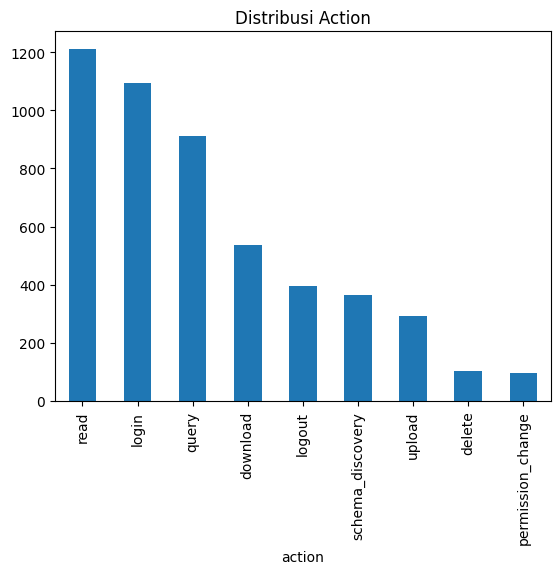

In [9]:
stream_event['action'].value_counts().plot(kind='bar')
plt.title('Distribusi Action')
plt.show()

### 6. Distribusi Status

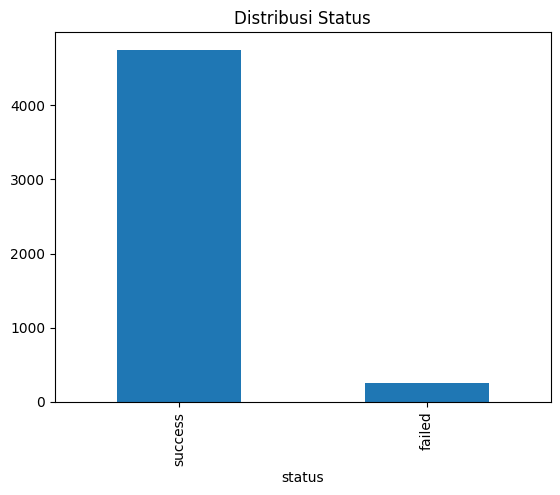

In [10]:
stream_event['status'].value_counts().plot(kind='bar')
plt.title('Distribusi Status')
plt.show()

### 7. Distribusi Classification

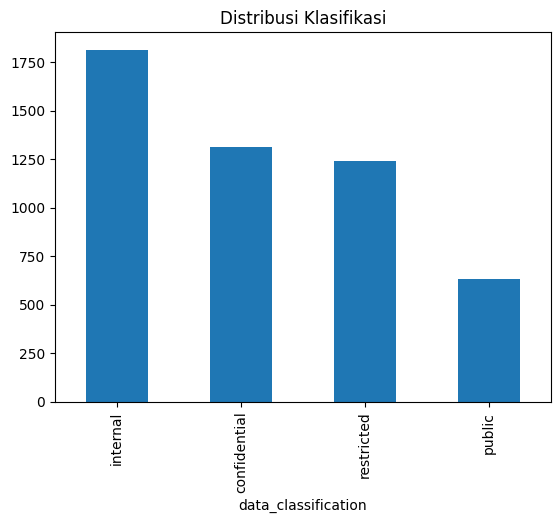

In [11]:
stream_event['data_classification'].value_counts().plot(kind='bar')
plt.title('Distribusi Klasifikasi')
plt.show()

### 8. Top User

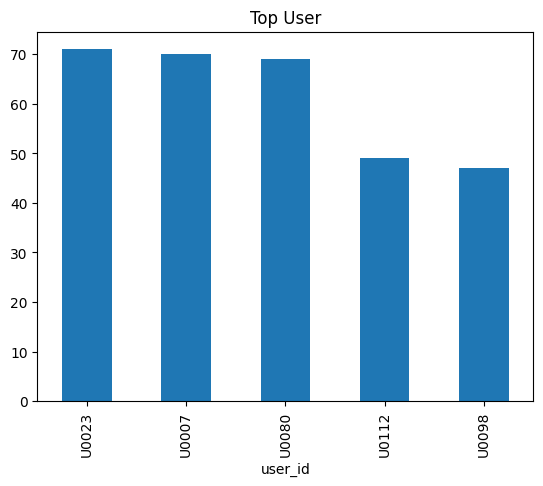

In [12]:
stream_event['user_id'].value_counts().head(5).plot(kind='bar')
plt.title('Top User')
plt.show()

### 9. Top Used Assets

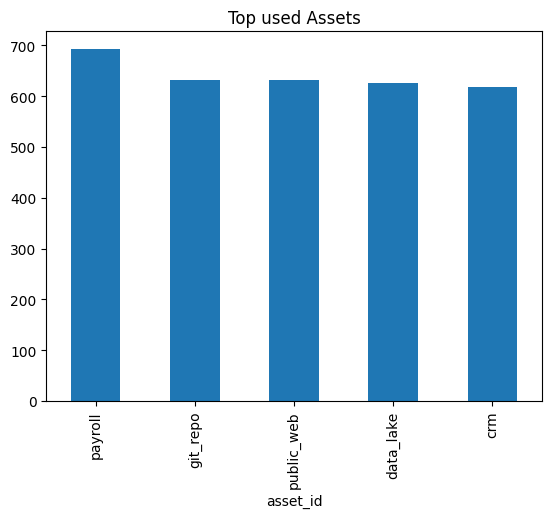

In [13]:
stream_event['asset_id'].value_counts().head(5).plot(kind='bar')
plt.title('Top used Assets')
plt.show()

## Bagian 4 - Data Dictionary

| No. | Nama Kolom | Tipe Data | Deskripsi |
|:--- | :--- | :---: | :--- |
|1. | event_id | string | identitas unik yang dimiliki oleh event |
|2. | event_time | datetime | waktu terjadinya event untuk analisis kronologi aktivitas |
|3. | user_id | string | identitas unik yang dimiliki oleh setiap pengguna yang melakukan aktivitas |
|4. | dept | string | departemen tempat kerja pengguna |
|5. | role | string | jabatan pengguna yang menentukan hak akses dalam sistem |
|6. | device_type | string | jenis perangkat yang digunakan untuk mengakses sistem |
|7. | source_ip | string | alamat ip pengguna saat mengakses sistem |
|8. | asset_id | string | identitas jenis aset yang diakses pengguna |
|9. | asset_type | string | jenis aset yang diakses |
|10. | data_classification | string | tingkat klasfikasi data yang diakses |
|11. | action | string | jenis aktivitas yang dilakukan pengguna |
|12. | status | string | status hasil dari aktivitas |
|13. | bytes_out | integer | jumlah data yang ditransfer keluar dari sistem |
|14. | records_accessed | integer | jumlah data yang diakses dalam 1 aktivitas |
|15. | latency_ms | float | waktu sistem merespon terhadap aktivitas pengguna |
|16. | risk_score | float | skor risiko yang menunjukkan seberapa tinggi ancaman tindakan terhadap sistem |
|17. | label | string | kategori akhir suatu aktivitas |

In [14]:
user.columns

Index(['user_id', 'employee_id', 'dept', 'role', 'clearance', 'location',
       'status'],
      dtype='object')

In [15]:
asset.columns

Index(['asset_id', 'asset_type', 'data_classification'], dtype='object')

In [16]:
stream_event.columns

Index(['event_id', 'event_time', 'user_id', 'dept', 'role', 'device_type',
       'source_ip', 'asset_id', 'asset_type', 'data_classification', 'action',
       'status', 'bytes_out', 'records_accessed', 'latency_ms', 'risk_score',
       'label'],
      dtype='object')

# 2. Data Science

## Bagian 1 - Merge Dataset
Gabungkan stream_event dengan user

In [17]:
merged = stream_event.merge(
    user,
    on = 'user_id',
    how = 'left'
)
merged.head()

,event_id,event_time,user_id,dept_x,role_x,device_type,source_ip,asset_id,asset_type,data_classification,...,records_accessed,latency_ms,risk_score,label,employee_id,dept_y,role_y,clearance,location,status_y
0,EVT0000001,2026-05-01T08:00:09,U0019,Sales,engineer,server,10.10.16.72,cust_db,database,restricted,...,8,67,32,normal,E00019,Sales,engineer,public,Jakarta,active
1,EVT0000002,2026-05-01T08:00:28,U0104,Legal,intern,workstation,10.10.2.40,git_repo,code,internal,...,13,145,4,normal,E00104,Legal,intern,confidential,Bandung,active
2,EVT0000003,2026-05-01T08:00:15,U0024,HR,intern,workstation,10.10.15.234,data_lake,storage,restricted,...,55,114,0,normal,E00024,HR,intern,restricted,Jakarta,active
3,EVT0000004,2026-05-01T08:00:40,U0121,HR,admin,laptop,10.10.13.179,ticketing,saas,internal,...,125,118,30,normal,E00121,HR,admin,internal,Jakarta,active
4,EVT0000005,2026-05-01T08:01:30,U0086,Engineering,director,server,10.10.16.116,bi_dashboard,dashboard,internal,...,24,187,8,normal,E00086,Engineering,director,internal,Bandung,active


## Bagian 2 - Membuat fitur analitik

In [18]:
event_per_user = merged.groupby('user_id').size().reset_index(name='event_count')
event_per_user.head()

,user_id,event_count
0,U0001,30
1,U0002,32
2,U0003,32
3,U0004,29
4,U0005,38


In [19]:
failed_login_rate = merged[merged['status_x'] == 'failed'].groupby('user_id').size().reset_index(name='failed_login_count')
failed_login_rate.head()

,user_id,failed_login_count
0,U0002,1
1,U0003,2
2,U0005,1
3,U0006,1
4,U0007,1


In [20]:
total_bytes_out = merged.groupby('user_id')['bytes_out'].sum().reset_index(name='total_bytes_out')
total_bytes_out.head()

,user_id,total_bytes_out
0,U0001,2129978
1,U0002,2535694
2,U0003,2717586
3,U0004,1878513
4,U0005,3257952


In [21]:
access_to_restricted_ratio = merged[merged['data_classification'] == 'restricted'].groupby('user_id').size().reset_index(name='access_to_restricted_count')
access_to_restricted_ratio.head()

,user_id,access_to_restricted_count
0,U0001,7
1,U0002,9
2,U0003,9
3,U0004,5
4,U0005,9


In [22]:
avg_latency = merged.groupby('user_id')['latency_ms'].mean().reset_index(name='avg_latency_ms')
avg_latency.head()

,user_id,avg_latency_ms
0,U0001,121.500000
1,U0002,99.250000
2,U0003,113.562500
3,U0004,123.275862
4,U0005,119.157895


In [23]:
merged = stream_event.merge(
    user,
    on = 'user_id',
    how = 'left'
)

features = (
    event_per_user
    .merge(failed_login_rate, on='user_id', how='left')
    .merge(total_bytes_out, on='user_id', how='left')
    .merge(access_to_restricted_ratio, on='user_id', how='left')
    .merge(avg_latency, on='user_id', how='left')
)

features = features.fillna(0)

merged = merged.merge(
    features,
    on='user_id',
    how='left'
)
merged.head()

,event_id,event_time,user_id,dept_x,role_x,device_type,source_ip,asset_id,asset_type,data_classification,...,dept_y,role_y,clearance,location,status_y,event_count,failed_login_count,total_bytes_out,access_to_restricted_count,avg_latency_ms
0,EVT0000001,2026-05-01T08:00:09,U0019,Sales,engineer,server,10.10.16.72,cust_db,database,restricted,...,Sales,engineer,public,Jakarta,active,25,0.0,1757792,7,120.840000
1,EVT0000002,2026-05-01T08:00:28,U0104,Legal,intern,workstation,10.10.2.40,git_repo,code,internal,...,Legal,intern,confidential,Bandung,active,37,1.0,3165515,11,107.378378
2,EVT0000003,2026-05-01T08:00:15,U0024,HR,intern,workstation,10.10.15.234,data_lake,storage,restricted,...,HR,intern,restricted,Jakarta,active,36,2.0,3082468,8,126.166667
3,EVT0000004,2026-05-01T08:00:40,U0121,HR,admin,laptop,10.10.13.179,ticketing,saas,internal,...,HR,admin,internal,Jakarta,active,39,1.0,3024972,12,118.717949
4,EVT0000005,2026-05-01T08:01:30,U0086,Engineering,director,server,10.10.16.116,bi_dashboard,dashboard,internal,...,Engineering,director,internal,Bandung,active,34,3.0,2658988,11,142.941176


## Bagian 3 - EDA dengan Visualisasi

### 1. Distribusi Label Event

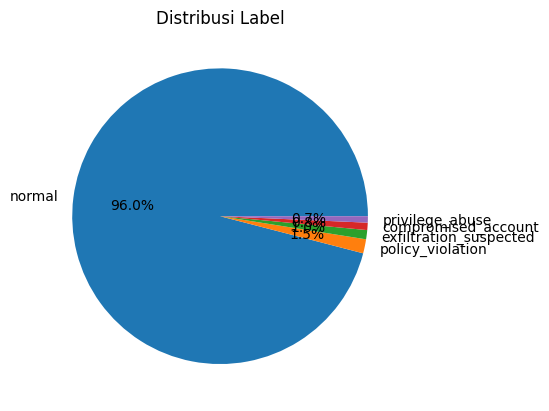

In [24]:
stream_event['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title('Distribusi Label')
plt.show()

### 2. Distribusi Risk Score

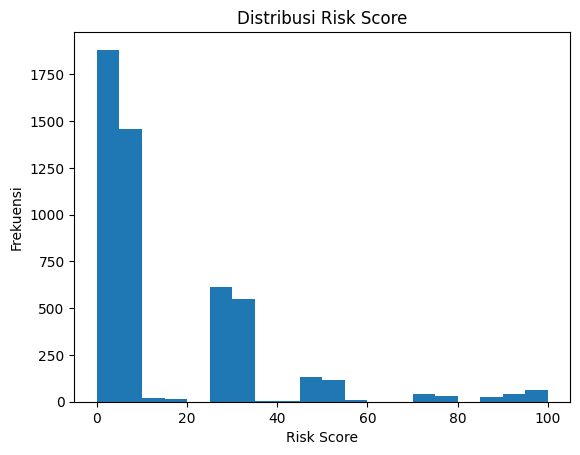

In [25]:
plt.hist(stream_event['risk_score'], bins=20)
plt.title('Distribusi Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Frekuensi')
plt.show()

### 3. Boxplot Risk Score berdasarkan Label

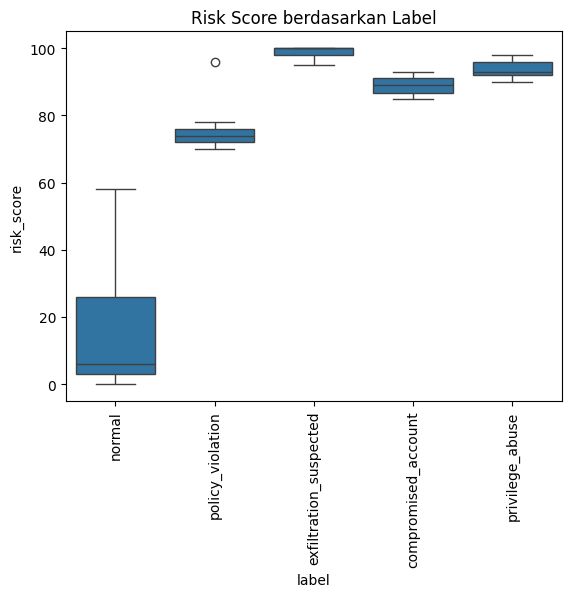

In [26]:
sns.boxplot(
    data=stream_event,
    x='label',
    y='risk_score'
)
plt.xticks(rotation=90)
plt.title('Risk Score berdasarkan Label')
plt.show()

### 4. Persebaran Risk Score berdasarkan Bytes Out

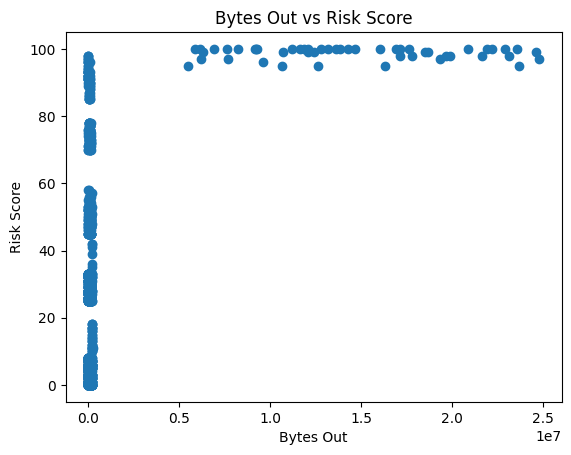

In [27]:
plt.scatter(
    stream_event['bytes_out'],
    stream_event['risk_score']
)

plt.xlabel('Bytes Out')
plt.ylabel('Risk Score')
plt.title('Bytes Out vs Risk Score')
plt.show()

## Bagian 4 - Model Deteksi Anomali / Klasifikasi

In [28]:
X = merged[
[
'event_count',
'failed_login_count',
'total_bytes_out',
'access_to_restricted_count',
'avg_latency_ms'
]
]

In [29]:
y = merged['label']

In [30]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)

## Bagian 5 - Evaluasi

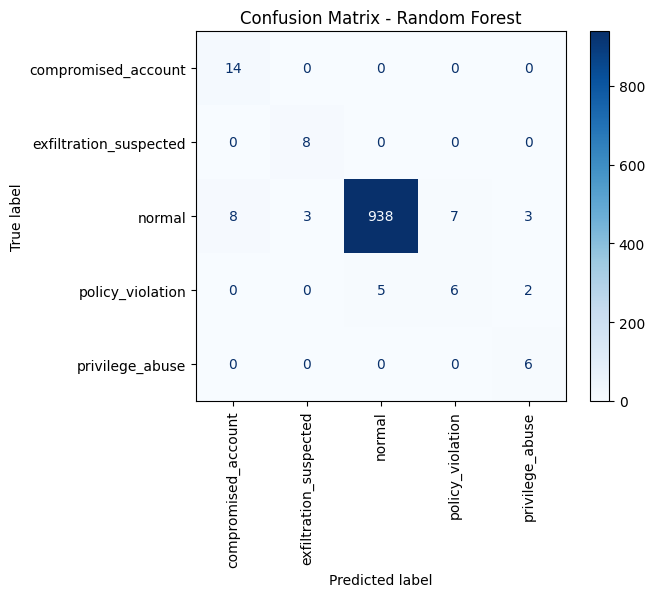

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediksi data test
y_pred = rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf.classes_
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xticks(rotation=90)
plt.show()

In [32]:
print(classification_report(y_test,y_pred))

                        precision    recall  f1-score   support

   compromised_account       0.64      1.00      0.78        14
exfiltration_suspected       0.73      1.00      0.84         8
                normal       0.99      0.98      0.99       959
      policy_violation       0.46      0.46      0.46        13
       privilege_abuse       0.55      1.00      0.71         6

              accuracy                           0.97      1000
             macro avg       0.67      0.89      0.75      1000
          weighted avg       0.98      0.97      0.97      1000



In [33]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print(scores)
print("Mean F1 Macro:", scores.mean())

[0.69113918 0.7908104  0.66828026 0.69295553 0.71128194]
Mean F1 Macro: 0.71089346320897


# 3. Data Security

## Bagian 1 - Menemukan pola risiko

### 1. Akses dari Terminated User (Inactive User)

In [37]:
risk1 = merged[merged['status_y'] != 'active']

risk1_summary = (
    risk1.groupby(['user_id', 'status_y', 'dept_y'])
    .agg(
        jumlah_event=('event_id', 'count'),
        total_bytes_out=('bytes_out', 'sum'),
        avg_risk_score=('risk_score', 'mean'),
        max_risk_score=('risk_score', 'max')
    )
    .reset_index()
    .sort_values('jumlah_event', ascending=False)
)

risk1_summary.head(10)

,user_id,status_y,dept_y,jumlah_event,total_bytes_out,avg_risk_score,max_risk_score
1,U0023,terminated,Legal,71,4750225,71.788732,93
0,U0007,terminated,Engineering,70,731551337,87.114286,100
4,U0080,terminated,Data Science,69,2831400,77.768116,98
7,U0108,terminated,HR,37,3273072,60.567568,78
3,U0070,terminated,Sales,35,3125802,49.600000,77
5,U0090,terminated,Sales,34,2367031,49.941176,77
2,U0067,terminated,Finance,33,2433662,49.303030,78
6,U0091,terminated,Engineering,28,1910083,50.535714,76
8,U0139,terminated,Data Science,28,2307617,62.571429,78
9,U0146,terminated,Operations,28,2198013,61.821429,78


### 2. Download Besar dari Data Confidental / Restricted

In [38]:
risk2 = merged[
    (merged['data_classification'].isin(['confidential','restricted'])) &
    (merged['bytes_out'] > merged['bytes_out'].quantile(0.95))
]

risk2_summary = (
    risk2.groupby(['user_id', 'asset_id', 'data_classification', 'action'])
    .agg(
        jumlah_event=('event_id', 'count'),
        total_bytes_out=('bytes_out', 'sum'),
        avg_risk_score=('risk_score', 'mean')
    )
    .reset_index()
    .sort_values('total_bytes_out', ascending=False)
)

risk2_summary.head(10)

,user_id,asset_id,data_classification,action,jumlah_event,total_bytes_out,avg_risk_score
1,U0007,payroll,confidential,download,50,729799409,98.8
41,U0066,payroll,confidential,login,2,416158,9.0
49,U0083,data_lake,restricted,read,2,395024,6.5
43,U0072,cust_db,restricted,upload,1,230966,42.0
36,U0059,cust_db,restricted,schema_discovery,1,230723,10.0
86,U0134,crm,confidential,schema_discovery,1,225879,42.0
53,U0088,data_lake,restricted,login,1,224165,11.0
68,U0112,crm,confidential,read,1,222342,17.0
63,U0104,payroll,confidential,read,1,221548,11.0
90,U0145,cust_db,restricted,schema_discovery,1,217173,12.0


### 3. Permision change dari IP eksternal

In [41]:
merged['is_external_ip'] = ~merged['source_ip'].str.startswith('10.10.')

risk3 = merged[
    (merged['action'] == 'permission_change') &
    (merged['is_external_ip'])
].copy()

risk3_summary = (
    risk3.groupby(['user_id', 'source_ip', 'dept_y', 'role_y', 'status_y'])
    .agg(
        jumlah_event=('event_id', 'count'),
        avg_risk_score=('risk_score', 'mean'),
        max_risk_score=('risk_score', 'max')
    )
    .reset_index()
    .sort_values('jumlah_event', ascending=False)
)

risk3_summary.head(10)

,user_id,source_ip,dept_y,role_y,status_y,jumlah_event,avg_risk_score,max_risk_score
3,U0080,8.8.8.8,Data Science,manager,terminated,10,93.900000,98
2,U0080,45.77.21.13,Data Science,manager,terminated,10,94.000000,98
1,U0080,185.220.101.2,Data Science,manager,terminated,8,94.375000,98
0,U0080,103.12.44.9,Data Science,manager,terminated,7,92.285714,94


## Bagian 2 - Memuat stream_generator.py

In [42]:
%%writefile stream_generator.py

import argparse
import json
import random
import time
from datetime import datetime, timedelta

DEPTS = [
    'Finance', 'HR', 'Engineering', 'Sales',
    'Legal', 'Data Science', 'Operations'
]

ROLES = [
    'analyst', 'manager', 'engineer',
    'director', 'intern', 'admin'
]

DEVICES = [
    'laptop', 'mobile', 'workstation',
    'server', 'vpn_gateway'
]

ASSETS = [
    ('cust_db', 'database', 'restricted'),
    ('payroll', 'database', 'confidential'),
    ('crm', 'saas', 'confidential'),
    ('data_lake', 'storage', 'restricted'),
    ('git_repo', 'code', 'internal'),
    ('bi_dashboard', 'dashboard', 'internal'),
    ('public_web', 'web', 'public'),
    ('ticketing', 'saas', 'internal')
]


def build_users(n=150, seed=42):

    random.seed(seed)

    users = []

    for i in range(1, n + 1):

        users.append({
            'user_id': f'U{i:04d}',
            'dept': random.choice(DEPTS),
            'role': random.choice(ROLES),
            'clearance': random.choice(
                ['public', 'internal', 'confidential', 'restricted']
            ),
            'status': random.choices(
                ['active', 'terminated'],
                weights=[95, 5]
            )[0]
        })

    for idx in [6, 22, 79]:
        if idx < len(users):
            users[idx]['status'] = 'terminated'

    return users


def event_stream(total=1000, seed=42):

    random.seed(seed)

    users = build_users(seed=seed)

    start = datetime.now().replace(microsecond=0)

    for n in range(1, total + 1):

        u = random.choice(users)

        asset = random.choice(ASSETS)

        action = random.choices(
            [
                'login',
                'logout',
                'read',
                'query',
                'download',
                'upload',
                'delete',
                'permission_change',
                'schema_discovery'
            ],
            weights=[22, 8, 25, 18, 10, 6, 2, 1, 1]
        )[0]

        bytes_out = max(
            0,
            int(random.gauss(80000, 50000))
        )

        src = f"10.10.{random.randint(1,20)}.{random.randint(2,254)}"

        status = random.choices(
            ['success', 'failed'],
            weights=[90, 10]
        )[0]

        risk = 0

        if u['status'] == 'terminated':
            risk += 45

        if action in ['delete', 'permission_change']:
            risk += 25

        if (
            asset[2] in ['restricted', 'confidential']
            and u['clearance'] in ['public', 'internal']
        ):
            risk += 25

        if bytes_out > 200000:
            risk += 10

        label = 'normal'

        # Exfiltration
        if n in range(
            int(total * 0.20),
            int(total * 0.20) + 20
        ):

            u = users[22]

            asset = (
                'payroll',
                'database',
                'confidential'
            )

            action = 'download'

            bytes_out = random.randint(
                5_000_000,
                10_000_000
            )

            src = '185.220.101.2'

            status = 'success'

            risk = 95

            label = 'exfiltration_suspected'

        # Compromised account
        elif n in range(
            int(total * 0.55),
            int(total * 0.55) + 20
        ):

            u = users[22]

            asset = (
                'cust_db',
                'database',
                'restricted'
            )

            action = random.choice([
                'login',
                'query',
                'schema_discovery'
            ])

            bytes_out = random.randint(
                100_000,
                1_000_000
            )

            src = '45.77.21.13'

            status = random.choice([
                'failed',
                'success'
            ])

            risk = 85

            label = 'compromised_account'

        # Privilege abuse
        elif n in range(
            int(total * 0.80),
            int(total * 0.80) + 15
        ):

            u = users[79]

            asset = (
                'git_repo',
                'code',
                'internal'
            )

            action = 'permission_change'

            bytes_out = 0

            src = '103.12.44.9'

            status = 'success'

            risk = 90

            label = 'privilege_abuse'

        elif risk >= 60:

            label = 'policy_violation'

        yield {

            'event_id': f'EVT{n:07d}',

            'event_time':
                (start + timedelta(seconds=n * 10))
                .isoformat(),

            'user_id': u['user_id'],

            'dept': u['dept'],

            'role': u['role'],

            'device_type': random.choice(
                DEVICES
            ),

            'source_ip': src,

            'asset_id': asset[0],

            'asset_type': asset[1],

            'data_classification': asset[2],

            'action': action,

            'status': status,

            'bytes_out': bytes_out,

            'records_accessed':
                max(
                    0,
                    int(
                        bytes_out /
                        random.randint(100, 1000)
                    )
                ),

            'latency_ms':
                max(
                    1,
                    int(
                        random.gauss(120, 20)
                    )
                ),

            'risk_score':
                min(
                    100,
                    risk + random.randint(0, 8)
                ),

            'label': label
        }


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        '--events',
        type=int,
        default=1000
    )

    parser.add_argument(
        '--speed',
        type=float,
        default=0.0
    )

    parser.add_argument(
        '--out',
        default='stream_events.jsonl'
    )

    args = parser.parse_args()

    with open(
        args.out,
        'w',
        encoding='utf8'
    ) as f:

        for event in event_stream(args.events):

            line = json.dumps(
                event,
                ensure_ascii=False
            )

            print(line)

            f.write(line + '\n')

            if args.speed > 0:
                time.sleep(args.speed)


if __name__ == '__main__':
    main()

Writing stream_generator.py


In [43]:
!python stream_generator.py --events 100000 --speed 0.05 --out stream_events.jsonl

{"event_id": "EVT0000001", "event_time": "2026-06-13T16:56:06", "user_id": "U0137", "dept": "Operations", "role": "admin", "device_type": "server", "source_ip": "10.10.3.166", "asset_id": "cust_db", "asset_type": "database", "data_classification": "restricted", "action": "upload", "status": "success", "bytes_out": 18209, "records_accessed": 63, "latency_ms": 103, "risk_score": 0, "label": "normal"}
{"event_id": "EVT0000002", "event_time": "2026-06-13T16:56:16", "user_id": "U0067", "dept": "Data Science", "role": "intern", "device_type": "server", "source_ip": "10.10.13.73", "asset_id": "public_web", "asset_type": "web", "data_classification": "public", "action": "read", "status": "success", "bytes_out": 36452, "records_accessed": 101, "latency_ms": 125, "risk_score": 1, "label": "normal"}
{"event_id": "EVT0000003", "event_time": "2026-06-13T16:56:26", "user_id": "U0121", "dept": "Sales", "role": "admin", "device_type": "laptop", "source_ip": "10.10.8.168", "asset_id": "cust_db", "asset

In [44]:
import importlib
import stream_generator

importlib.reload(stream_generator)

<module 'stream_generator' from '/content/stream_generator.py'>

In [45]:
for trx in stream_generator.event_stream(5):
    print(trx)

{'event_id': 'EVT0000001', 'event_time': '2026-06-13T16:57:41', 'user_id': 'U0023', 'dept': 'Operations', 'role': 'engineer', 'device_type': 'mobile', 'source_ip': '185.220.101.2', 'asset_id': 'payroll', 'asset_type': 'database', 'data_classification': 'confidential', 'action': 'download', 'status': 'success', 'bytes_out': 8873007, 'records_accessed': 58761, 'latency_ms': 103, 'risk_score': 99, 'label': 'exfiltration_suspected'}
{'event_id': 'EVT0000002', 'event_time': '2026-06-13T16:57:51', 'user_id': 'U0023', 'dept': 'Operations', 'role': 'engineer', 'device_type': 'workstation', 'source_ip': '185.220.101.2', 'asset_id': 'payroll', 'asset_type': 'database', 'data_classification': 'confidential', 'action': 'download', 'status': 'success', 'bytes_out': 8536342, 'records_accessed': 8947, 'latency_ms': 149, 'risk_score': 96, 'label': 'exfiltration_suspected'}
{'event_id': 'EVT0000003', 'event_time': '2026-06-13T16:58:01', 'user_id': 'U0023', 'dept': 'Operations', 'role': 'engineer', 'dev

## Bagian 3 - Membuat Security_Alert

In [46]:
def security_alert(event):

  #CRITICAL
  if (event['label'] in ['exfiltration_suspected', 'privilege_abuse']
      or event['risk_score'] >= 90
  ):
      return 'CRITICAL'

  #HIGH
  elif (event['data_classification'] in ['confidential', 'restricted']
        and event['bytes_out'] > 100000
  ):
      return 'HIGH'

  #MEDIUM
  elif (event['failed_login_count'] >= 3
        or event['risk_score'] >= 60
  ):
      return 'MEDIUM'

  #LOW
  else:
    return 'LOW'

In [47]:
for trx in stream_generator.event_stream(30):

  trx['failed_login_count'] = 0

  level = security_alert(trx)

  print(
      f"[{level}]"
      f"{trx['action']} | "
      f"{trx['user_id']} | "
      f"{trx['event_id']}"
  )

[LOW]upload | U0137 | EVT0000001
[LOW]read | U0067 | EVT0000002
[HIGH]query | U0121 | EVT0000003
[LOW]download | U0064 | EVT0000004
[HIGH]query | U0095 | EVT0000005
[CRITICAL]download | U0023 | EVT0000006
[CRITICAL]download | U0023 | EVT0000007
[CRITICAL]download | U0023 | EVT0000008
[CRITICAL]download | U0023 | EVT0000009
[CRITICAL]download | U0023 | EVT0000010
[CRITICAL]download | U0023 | EVT0000011
[CRITICAL]download | U0023 | EVT0000012
[CRITICAL]download | U0023 | EVT0000013
[CRITICAL]download | U0023 | EVT0000014
[CRITICAL]download | U0023 | EVT0000015
[CRITICAL]download | U0023 | EVT0000016
[CRITICAL]download | U0023 | EVT0000017
[CRITICAL]download | U0023 | EVT0000018
[CRITICAL]download | U0023 | EVT0000019
[CRITICAL]download | U0023 | EVT0000020
[CRITICAL]download | U0023 | EVT0000021
[CRITICAL]download | U0023 | EVT0000022
[CRITICAL]download | U0023 | EVT0000023
[CRITICAL]download | U0023 | EVT0000024
[CRITICAL]download | U0023 | EVT0000025
[CRITICAL]login | U0023 | EVT000002

In [48]:
import time
for trx in stream_generator.event_stream(10):
  trx['failed_login_count'] = 0
  level = security_alert(trx)
  print(
      f"[{level}]"
      f"{trx['action']} | "
      f"{trx['user_id']} | "
      f"{trx['event_id']}"
  )
  time.sleep(1)

[LOW]upload | U0137 | EVT0000001
[CRITICAL]download | U0023 | EVT0000002
[CRITICAL]download | U0023 | EVT0000003
[CRITICAL]download | U0023 | EVT0000004
[CRITICAL]download | U0023 | EVT0000005
[CRITICAL]download | U0023 | EVT0000006
[CRITICAL]download | U0023 | EVT0000007
[CRITICAL]download | U0023 | EVT0000008
[CRITICAL]download | U0023 | EVT0000009
[CRITICAL]download | U0023 | EVT0000010


In [49]:
stream_result = []

In [50]:
for trx in stream_generator.event_stream(100):
  trx['failed_login_count'] = 0
  level = security_alert(trx)
  trx ['alert_level'] = level
  stream_result.append(trx)

In [51]:
stream_df = pd.DataFrame(stream_result)

In [52]:
print(stream_df.head())

     event_id           event_time user_id          dept     role  \
0  EVT0000001  2026-06-13T16:58:08   U0137    Operations    admin   
1  EVT0000002  2026-06-13T16:58:18   U0067  Data Science   intern   
2  EVT0000003  2026-06-13T16:58:28   U0121         Sales    admin   
3  EVT0000004  2026-06-13T16:58:38   U0064         Sales  manager   
4  EVT0000005  2026-06-13T16:58:48   U0095    Operations  analyst   

   device_type     source_ip    asset_id asset_type data_classification  \
0       server   10.10.3.166     cust_db   database          restricted   
1       server   10.10.13.73  public_web        web              public   
2       laptop   10.10.8.168     cust_db   database          restricted   
3       mobile  10.10.16.173   data_lake    storage          restricted   
4  vpn_gateway   10.10.6.248         crm       saas        confidential   

     action   status  bytes_out  records_accessed  latency_ms  risk_score  \
0    upload  success      18209                63        

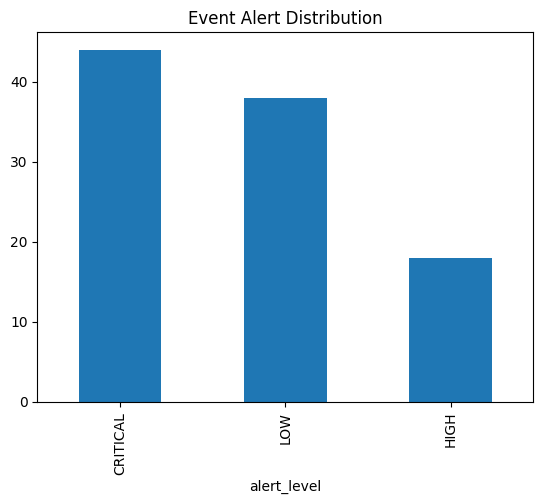

In [53]:
stream_df['alert_level'].value_counts().plot(
    kind='bar'
)
plt.title('Event Alert Distribution')
plt.show()

In [54]:
stream_df.to_csv(
    'event_alert_stream.csv',
    index=False
)

In [55]:
from google.colab import files

files.download('event_alert_stream.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>